In [73]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np

from model_utils import load_conv_model, load_cifar_tensor
from bottleneck_activation import get_bottleneck_activation

In [28]:
activation = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_bottleneck_activation.npy', allow_pickle=True).item()

In [29]:
test_images, _ = load_cifar_tensor()

Files already downloaded and verified
Files already downloaded and verified


In [32]:
pca_ae = load_conv_model('/home/david/cifar_models/pca-ae/39', 'pca-ae', 59)

In [76]:
import tqdm

activations = []
all_pca_nonzero_means = []


for iteration in tqdm.tqdm(range(5), desc=f"Evaluating all models", leave=True):
    pca = load_conv_model('/home/david/cifar_models/pca-ae/'+str(iteration), 'pca-ae', 59)

    for i in range(len(test_images)):
        test_image = test_images[i]
        num_images += 1
        activation = get_bottleneck_activation(pca, test_image)
        activations.append(activation)

Evaluating all models:   0%|          | 0/5 [00:00<?, ?it/s]


NameError: name 'num_images' is not defined

In [54]:
import matplotlib.pyplot as plt

In [60]:
all_pca_nonzero_means[0]

array([[16.560806 , 15.520653 ,  8.30673  ,  4.994234 ,  4.1135755,
         5.1197543,  2.6996093,  3.3345945,  3.7365801,  3.2953038,
         4.8343296,  2.7326112,  4.4991255,  3.676605 ,  2.7746181,
         2.291569 ,  2.9105725,  2.4225047,  1.8813881,  2.5949867,
         2.2237186,  2.6408792,  2.4699714,  2.7123191,  2.3261478,
         7.3104353,  3.0911052,  2.2866118,  2.0551915,  2.726401 ,
         5.184763 ,  2.0746522,  4.0868144,  5.5557537,  3.7320929,
         2.73932  ,  2.6526103,  2.6566646,  3.012779 ,  2.1684473,
         7.613982 ,  2.764345 ,  5.554959 ,  4.271702 ,  4.6809373,
         2.2294571,  3.7313375,  2.1235821,  2.8149097,  2.5837598,
         5.050108 ,  4.204597 ,  2.5417557,  1.8893903,  8.080521 ,
         3.2954268,  2.2820992,  3.3005762,  2.1271882,  2.3711686,
         4.173819 ,  6.8109436,  3.642851 ,  2.3842611,  2.6426735,
         4.1789064,  3.0512068,  3.0345075,  2.1292603,  3.5467563,
         1.8137507,  5.0639367,  2.0174444,  2.1

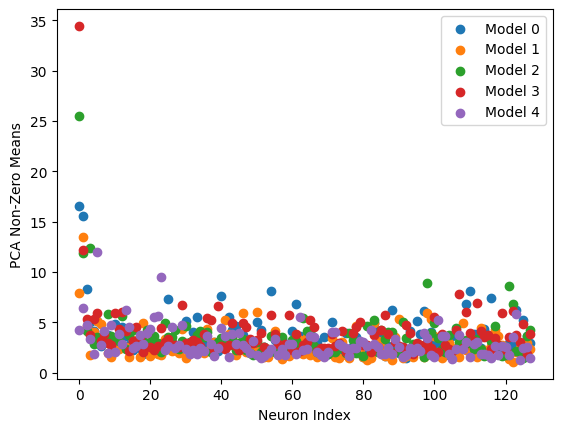

In [ ]:
# plot all values in here with 1 - len(all_pca_nonzero_means) on x axis and values on y axis on a scatter plot

for i in range(len(all_pca_nonzero_means)):
    plt.scatter([j for j in range(128)], all_pca_nonzero_means[i], label=f'Model {i}')

plt.xlabel('Neuron Index')
plt.ylabel('Activation')
plt.legend()
plt.show()